## Build model &compare

In [1]:
import pandas as pd 
import numpy as np

import model_utils
import adapter

In [2]:
start_date="2019-01-01"
test_date="2024-01-01"
end_date="2026-01-01"
freq="W"
n_states=3
window=104 #2 years （52*2）
random_seed=42

In [3]:
#forecast
train,test=model_utils.get_data(start_date,test_date,end_date,freq)
predicted_close = []
T = test.shape[0]-1 

model,log_likelihood=model_utils.build_hmm_and_score(train[-window:],n_states)

Loading data from cache...


In [4]:
import numpy as np
from hmmlearn.hmm import GaussianHMM


X_train = train[['Open','High','Low','Adj Close']].values
X_test = test[['Open','High','Low','Adj Close']].values
predicted_close = []

#initial fit
model,log_likelihood=model_utils.build_hmm_and_score(train[-window:],n_states)
# rolling forecast
for t in range(len(X_test)):
    if t < window:
        X_window = np.vstack([X_train[-(window-t):], X_test[:t]])
    else:
        X_window = X_test[t-window:t]
    
    model.fit(X_window)
    
    # predict test[t] close
    hidden_states = model.predict(X_window)
    # use last day Adj Close + HMM block match prediction
    O = X_window[-window:, :]
    logP_O = model.score(O)
    
    # find most similar historical block (train + past test)
    min_diff = np.inf
    T_star = None
    full_hist = np.vstack([X_train, X_test[:t]])
    for i in range(len(full_hist)-window):
        O_hist = full_hist[i:i+window, :]
        logP_hist = model.score(O_hist)
        diff = abs(logP_O - logP_hist)
        if diff < min_diff:
            min_diff = diff
            T_star = i
    
    # block match prediction
    O4_T = X_window[-1, 3]
    O4_Tstar_next = full_hist[T_star+window, 3]
    O4_Tstar = full_hist[T_star+window-1, 3]
    sign_term = np.sign(logP_O - model.score(full_hist[T_star:T_star+window, :]))
    O4_next = O4_T + (O4_Tstar_next - O4_Tstar) * sign_term
    predicted_close.append(O4_next)

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


In [5]:
#add date to predicted_close
predicted_close=pd.Series(predicted_close,index=test.index)

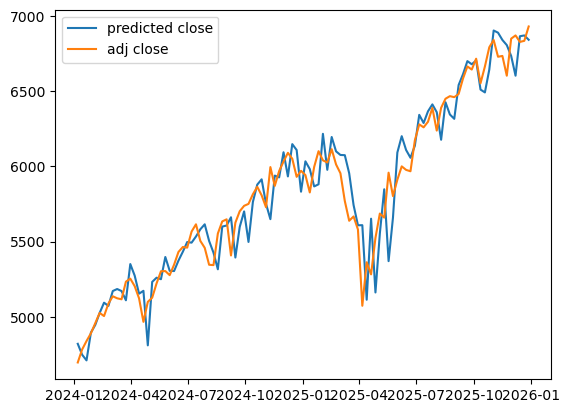

In [6]:
#draw predict close and adj close
import matplotlib.pyplot as plt
plt.plot(predicted_close,label='predicted close')
plt.plot(test['Adj Close'],label='adj close')
plt.legend()
plt.show()

In [22]:
trade_cost=0.0001
df=test.copy()

#pred return
pred_return=predicted_close.pct_change()
adj_return=pd.Series(df['Adj Close'].iloc[:, 0]).pct_change()

#only sell when predicted return lower than 0.03
weight = np.where(pred_return > 0.03,1.0,
                        np.where(pred_return > -0.05, 1.0, 0.0),)
strat_weight=pd.Series(weight,index=test.index)
#cost abs previous weight change
cost=abs(strat_weight-strat_weight.shift(1))*trade_cost
strat_return=strat_weight*adj_return-cost
strat_cumret=strat_return.cumsum().fillna(0)
adj_cumret=adj_return.cumsum().fillna(0)

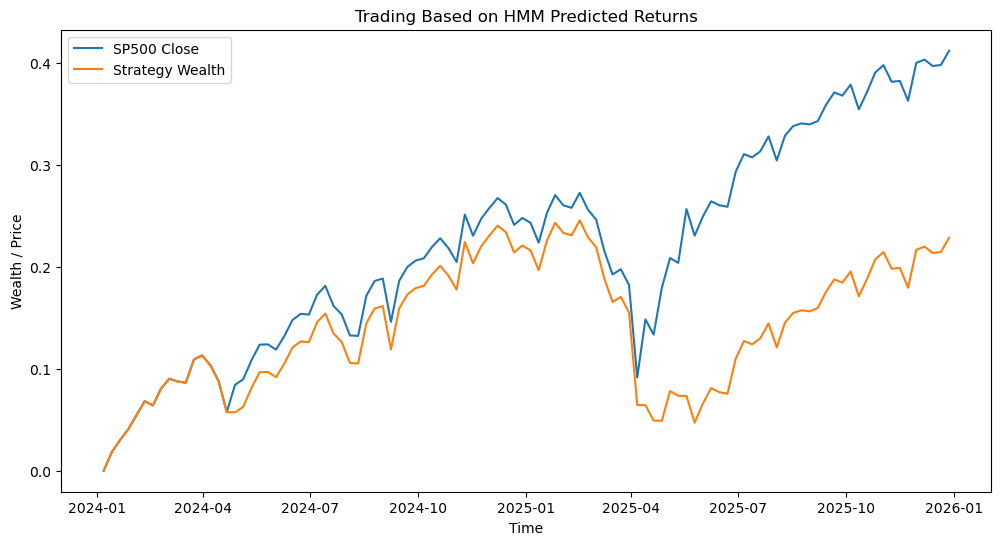

In [23]:
# compare with SP500
plt.figure(figsize=(12,6))
plt.plot(adj_cumret, label='SP500 Close')
plt.plot(strat_cumret, label='Strategy Wealth')
plt.xlabel('Time')
plt.ylabel('Wealth / Price')
plt.title('Trading Based on HMM Predicted Returns')
plt.legend()
plt.show()